In [1]:
import pickle
from cmdstanpy import CmdStanModel
import arviz as az

In [ ]:
"""
thin = 10 to prevent autocorrelation issues
iter_sampling = 10000 to get enough samples after thinning
"""

model = CmdStanModel(stan_file='trape7.stan')
fit = model.sample(data='trape_populations.json', show_console=False, show_progress=True, thin=10, iter_sampling=10000, chains=4, parallel_chains=4)

draws = fit.draws_pd()
draws.to_csv('trape7_draws.csv')
with open('trape7_fit.pickle', 'wb') as f:
    pickle.dump(fit, f)

In [2]:
with open('trape7_fit.pickle', 'rb') as f:
    fit = pickle.load(f)
# print(fit.diagnose())

In [3]:
z = az.from_cmdstanpy(fit)
z

Inference data with groups:
	> posterior
	> log_likelihood
	> sample_stats

In [12]:
i = 1
vars = ['lambda', 'rho_elp', 'tau_elp', 'rho_clinical', 'delta_clinical', 'gamma_clinical']
y = z.posterior.isel(lambda_dim_0=i, rho_elp_dim_0=i, tau_elp_dim_0=i, delta_clinical_dim_0=i, rho_clinical_dim_0=i, gamma_clinical_dim_0=i)


Rhat values good

In [13]:
print(az.rhat(y, var_names=vars))

<xarray.Dataset> Size: 96B
Dimensions:               ()
Coordinates:
    tau_elp_dim_0         int64 8B 1
    rho_elp_dim_0         int64 8B 1
    rho_clinical_dim_0    int64 8B 1
    lambda_dim_0          int64 8B 1
    delta_clinical_dim_0  int64 8B 1
    gamma_clinical_dim_0  int64 8B 1
Data variables:
    lambda                float64 8B 1.001
    rho_elp               float64 8B 1.0
    tau_elp               float64 8B 1.0
    rho_clinical          float64 8B 0.9998
    delta_clinical        float64 8B 1.0
    gamma_clinical        float64 8B 1.001


Effective samples sizes good

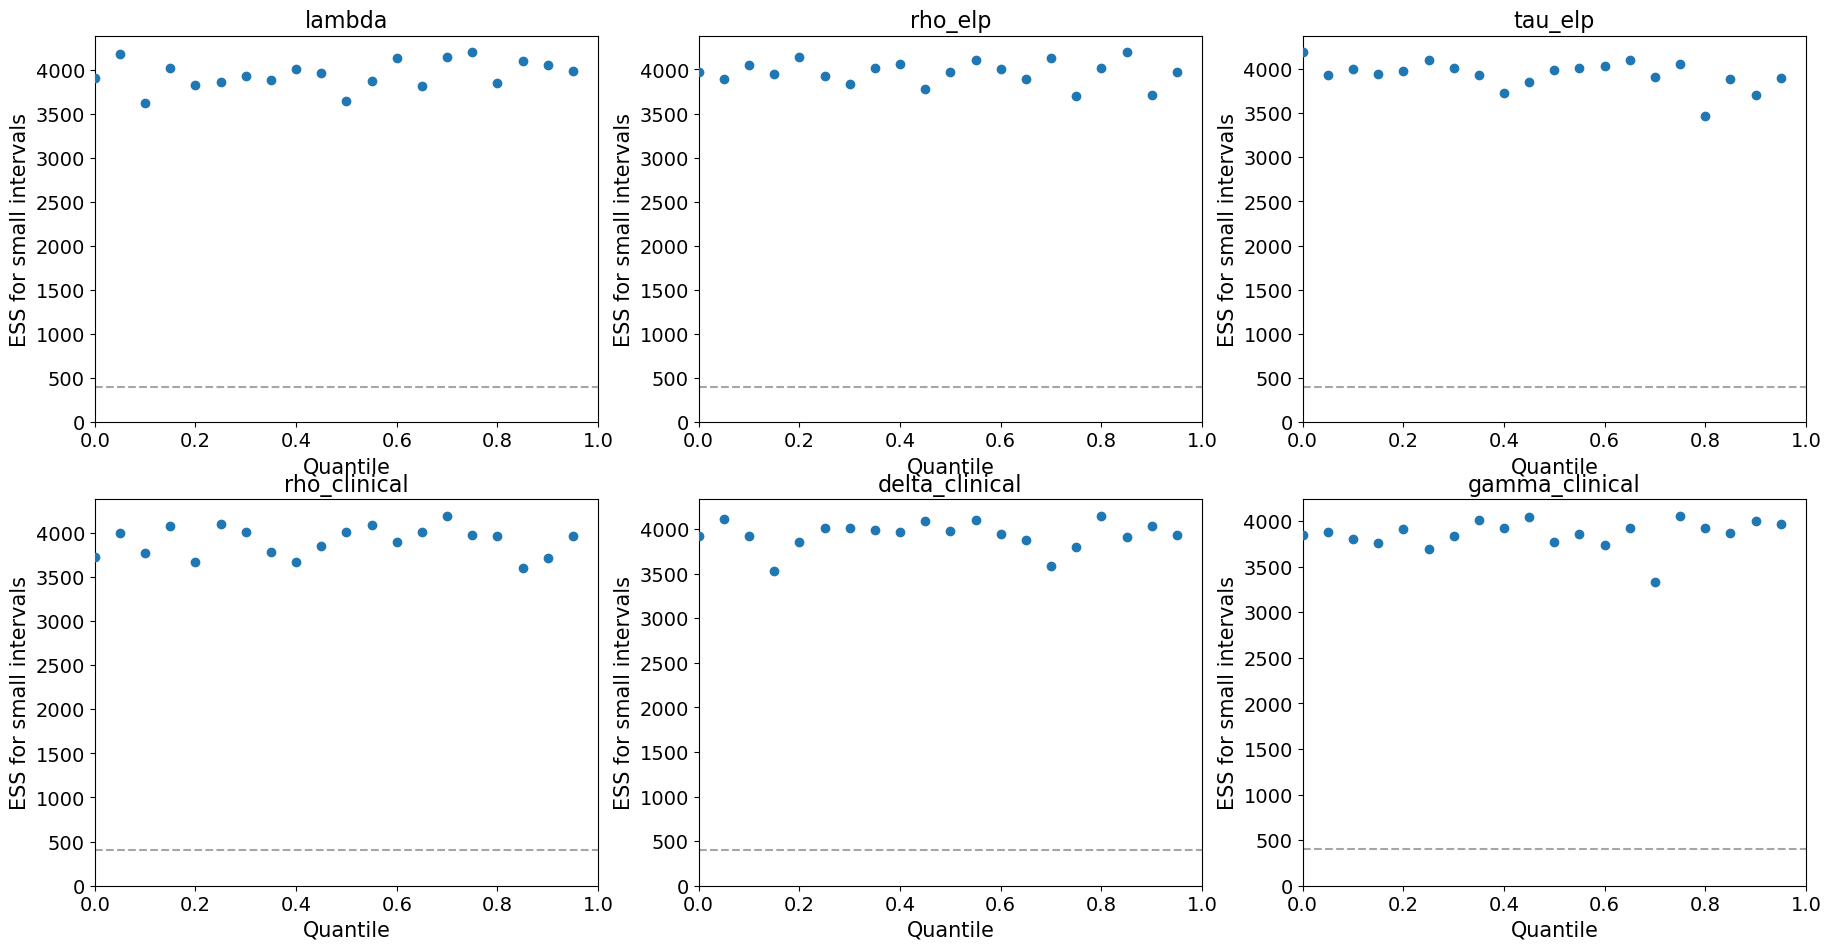

In [14]:
az.plot_ess(y, var_names=vars);

No autocorrelation with thin = 10

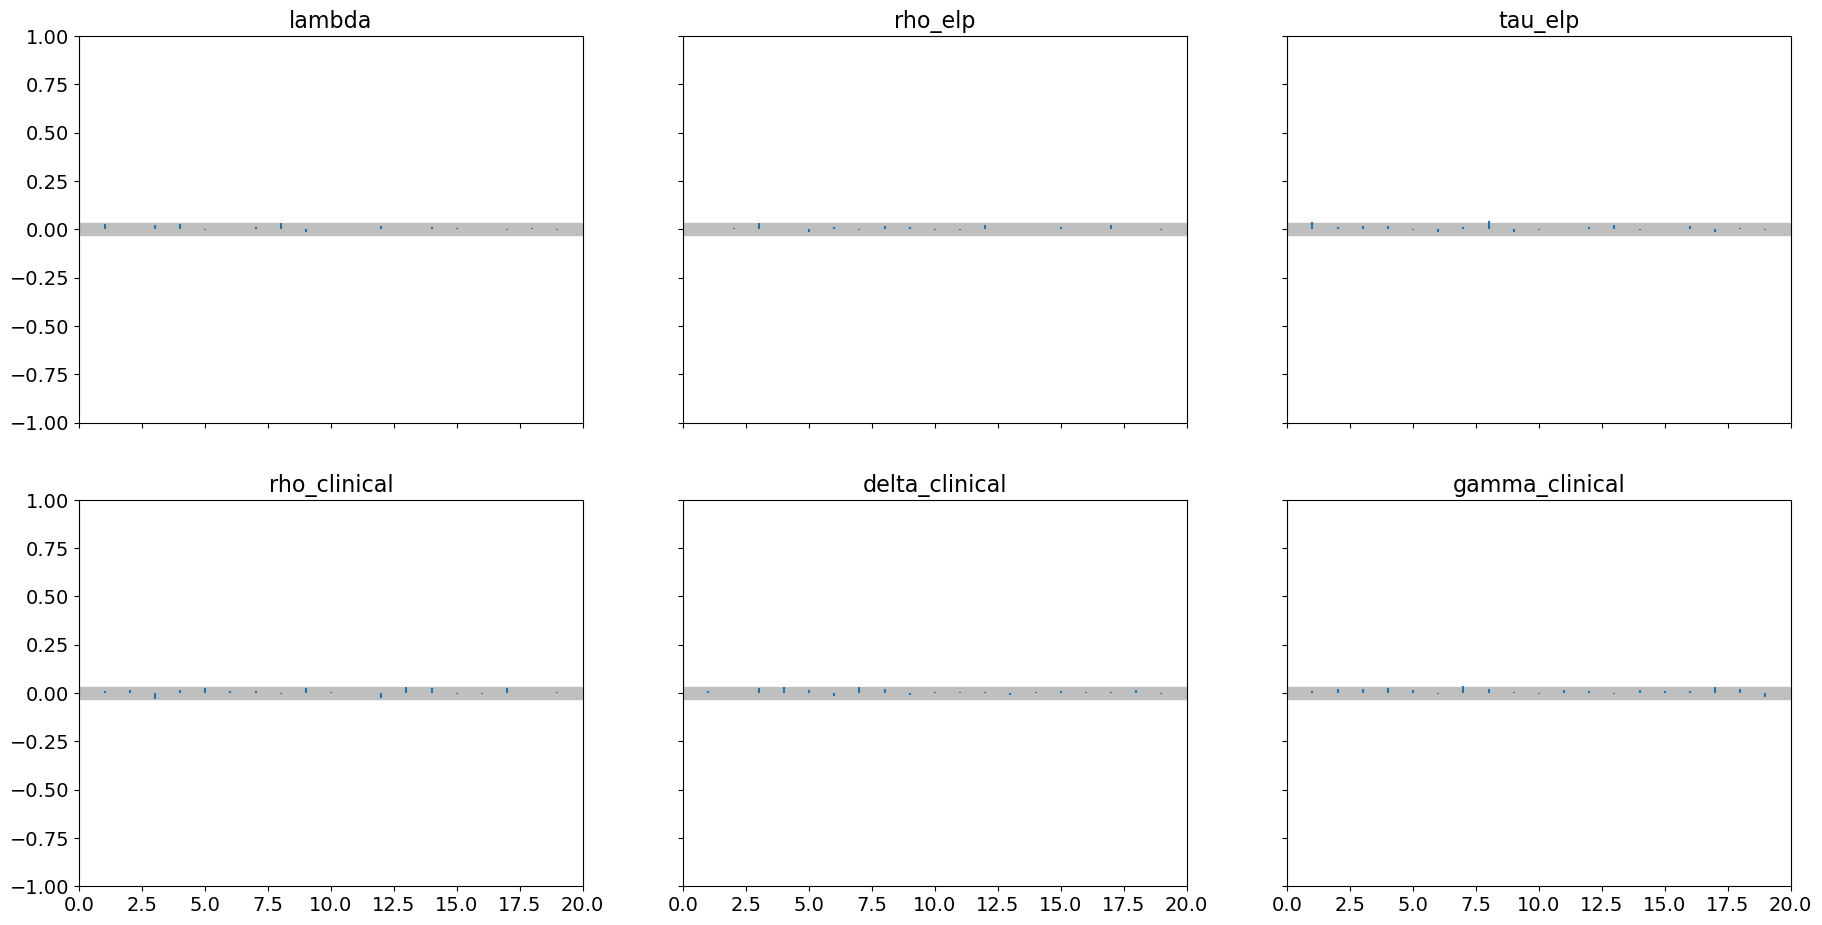

In [15]:
az.plot_autocorr(y, var_names=vars, combined=True, max_lag=20,);

Chains look good

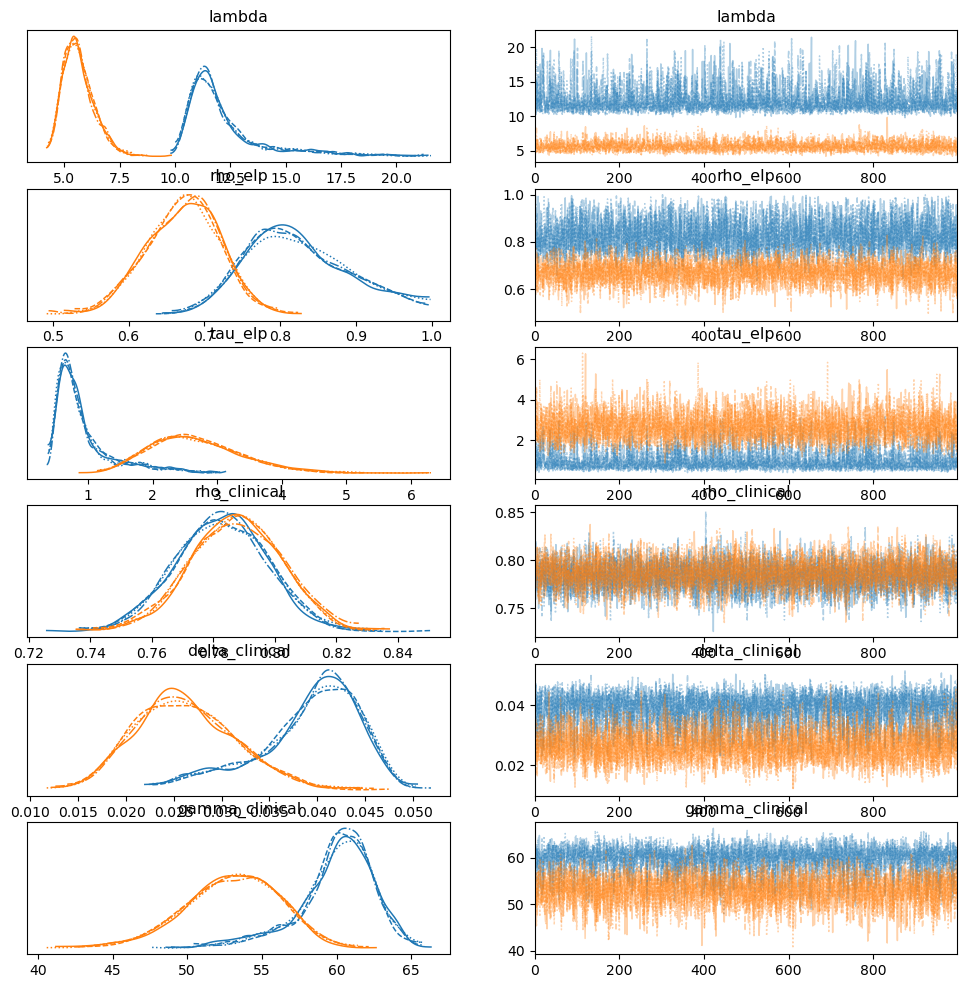

In [16]:
az.plot_trace(fit, var_names=vars);

Pair plot reveals identifiability issue between several parameters

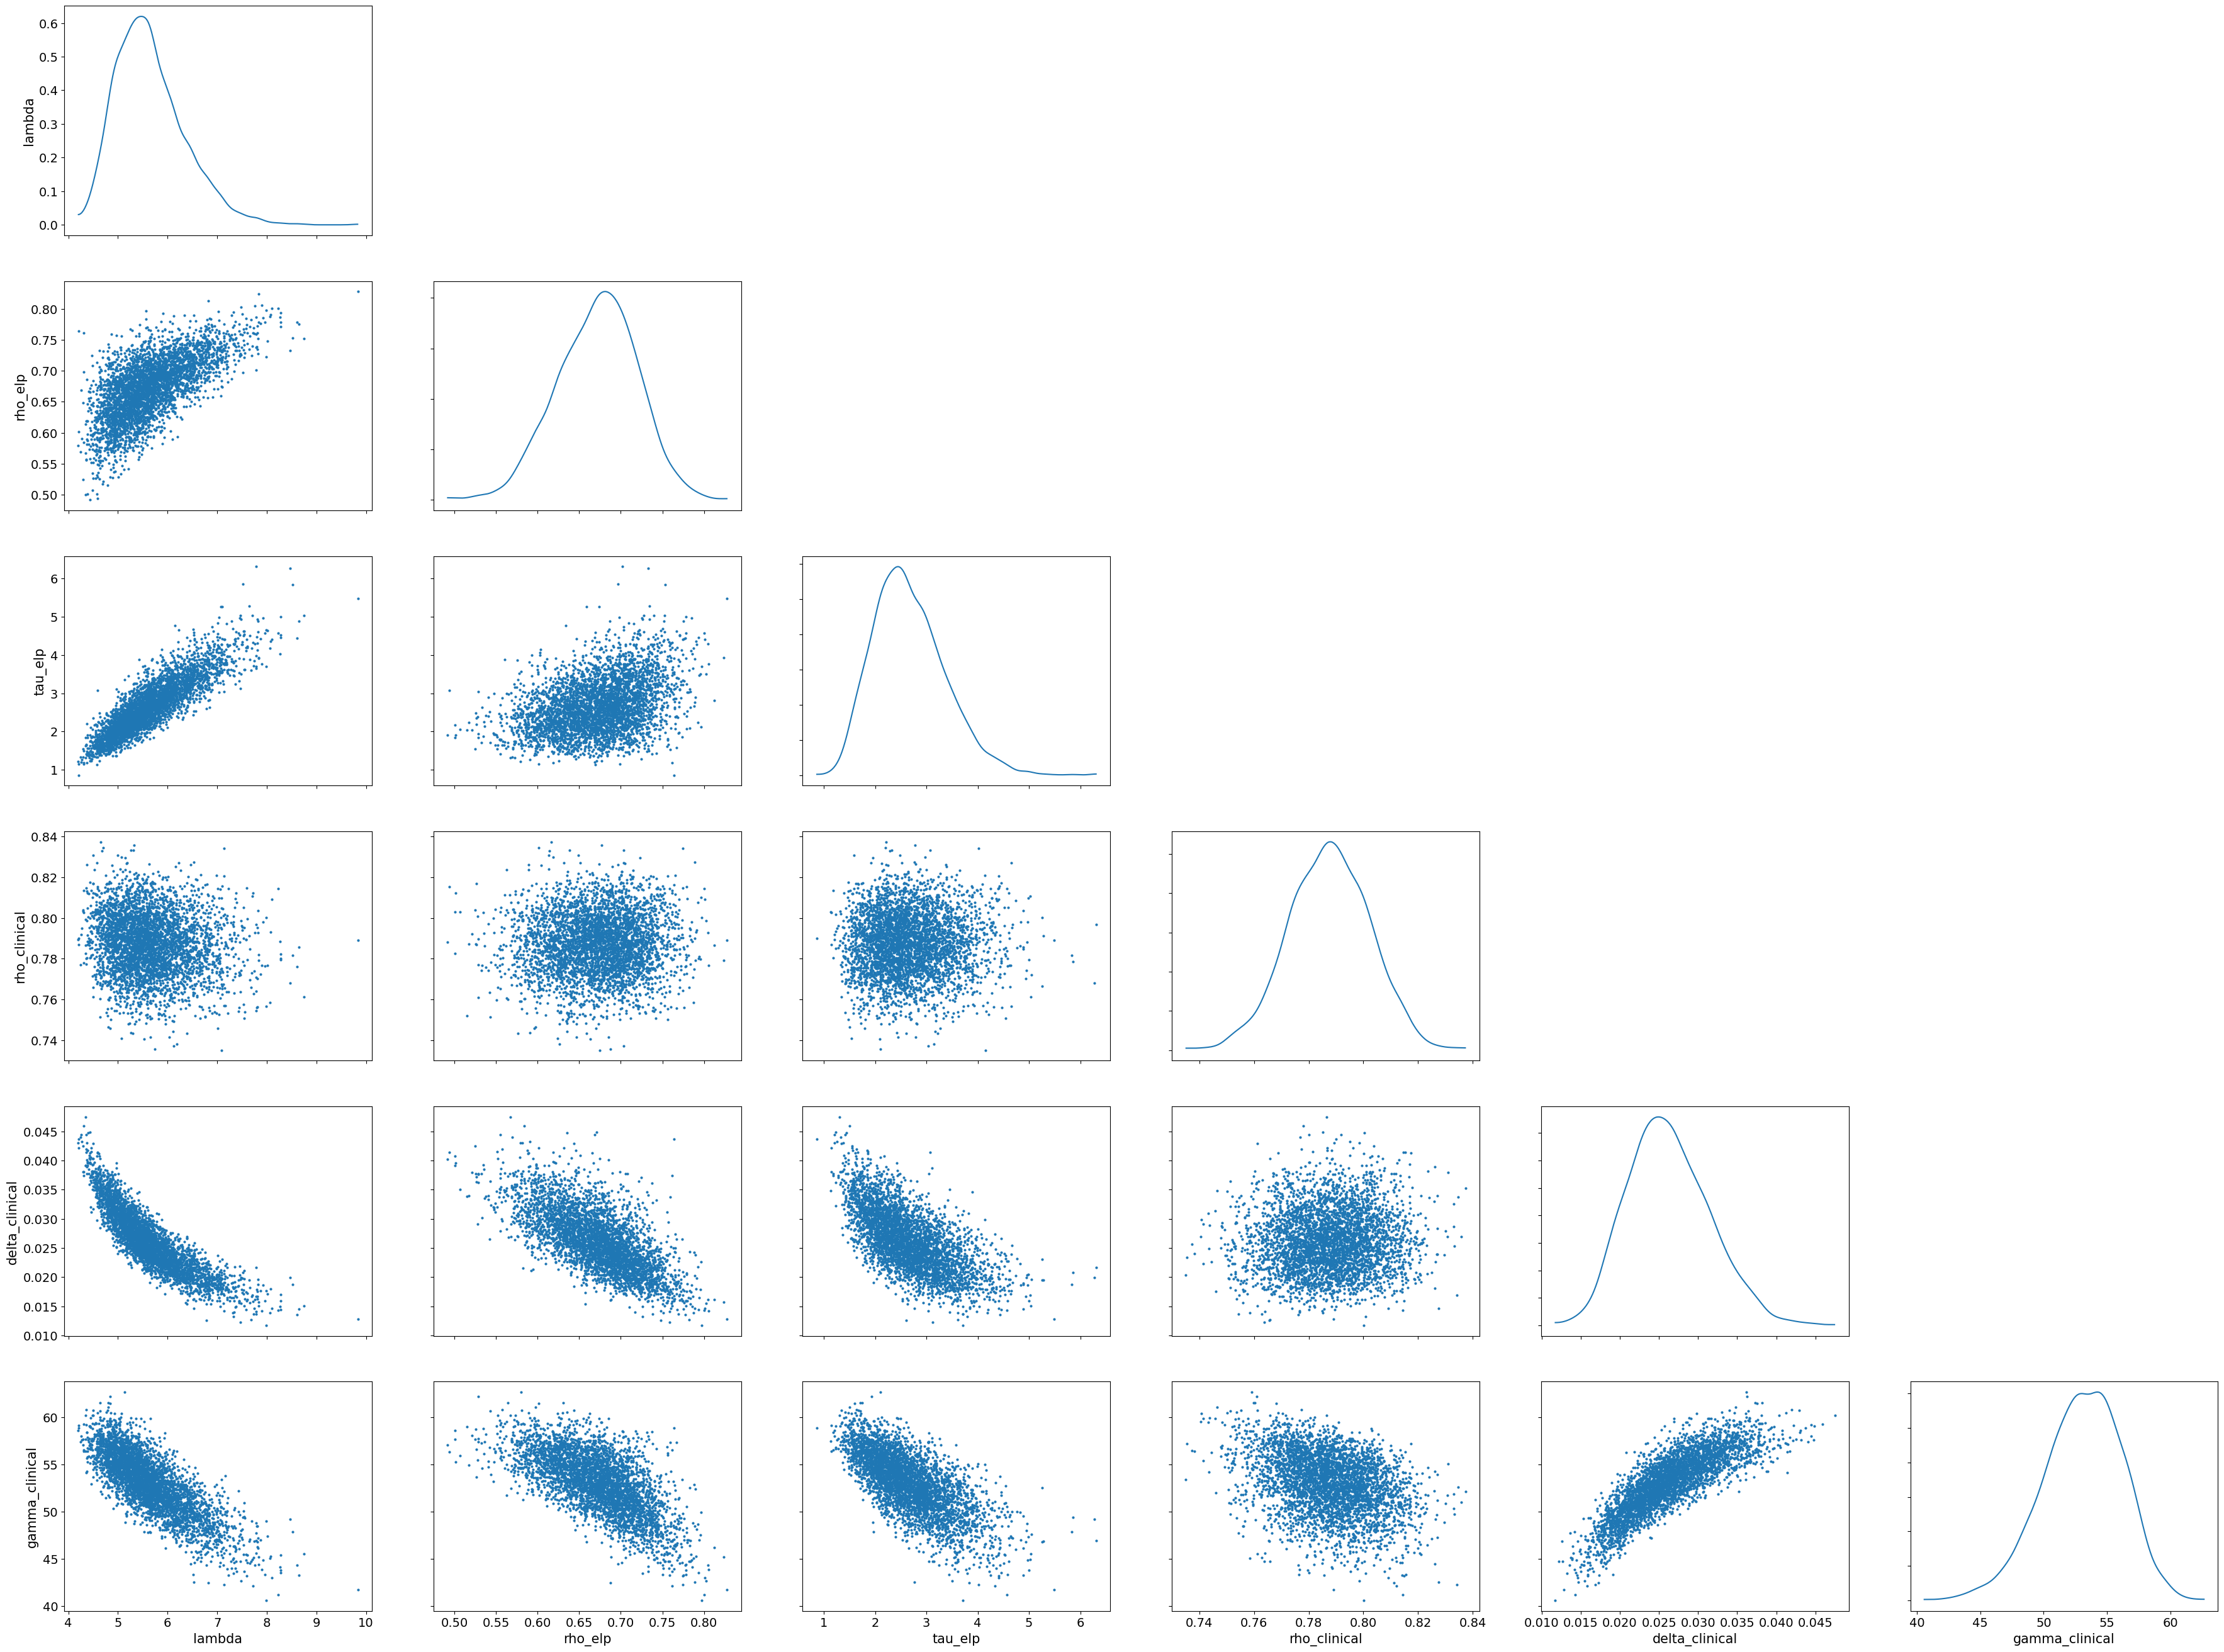

In [17]:
az.plot_pair(y, var_names=vars, marginals=True);